<a href="https://colab.research.google.com/github/leem928/AI_Project/blob/main/%EC%8B%AC%EC%A0%84%EB%8F%84_23619016_%EC%9D%B4%EB%AF%BC%EC%95%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 94.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
import os
import ast
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [ ]:
BASE_PATH = "/content/drive/MyDrive/ptb-xl/1.0.3"

df = pd.read_csv(
    f"{BASE_PATH}/ptbxl_database.csv"
)

scp = pd.read_csv(
    f"{BASE_PATH}/scp_statements.csv",
    index_col=0
)

print(df.shape)
print(scp.shape)

(21799, 28)
(71, 12)


In [ ]:
diag_map = scp[
    scp["diagnostic"] == 1
]["diagnostic_class"].to_dict()

def get_superclass(code_string):

    codes = ast.literal_eval(code_string)

    classes = set()

    for code in codes.keys():

        if code in diag_map:
            classes.add(diag_map[code])

    return list(classes)

df["superclass"] = df["scp_codes"].apply(
    get_superclass
)

In [ ]:
mi_df = df[
    df["superclass"].apply(
        lambda x: "MI" in x
    )
]

norm_df = df[
    df["superclass"].apply(
        lambda x: "NORM" in x
    )
]

print("MI :", len(mi_df))
print("NORM :", len(norm_df))

MI : 5469
NORM : 9514


In [ ]:
mi_df = mi_df.sample(
    n=500,
    random_state=42
)

norm_df = norm_df.sample(
    n=500,
    random_state=42
)

mi_df["label"] = 1
norm_df["label"] = 0

data_df = pd.concat(
    [mi_df, norm_df],
    ignore_index=True
)

print(data_df.shape)

(1000, 30)


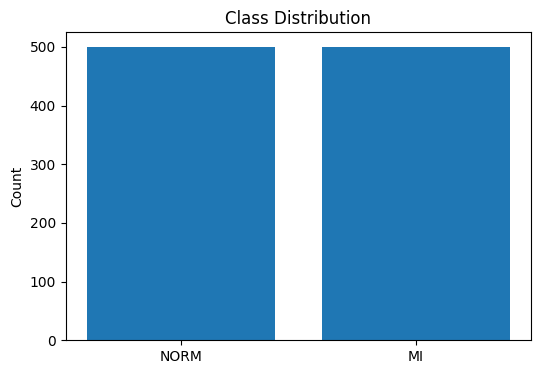

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    ["NORM","MI"],
    [len(norm_df), len(mi_df)]
)

plt.title("Class Distribution")
plt.ylabel("Count")

plt.show()

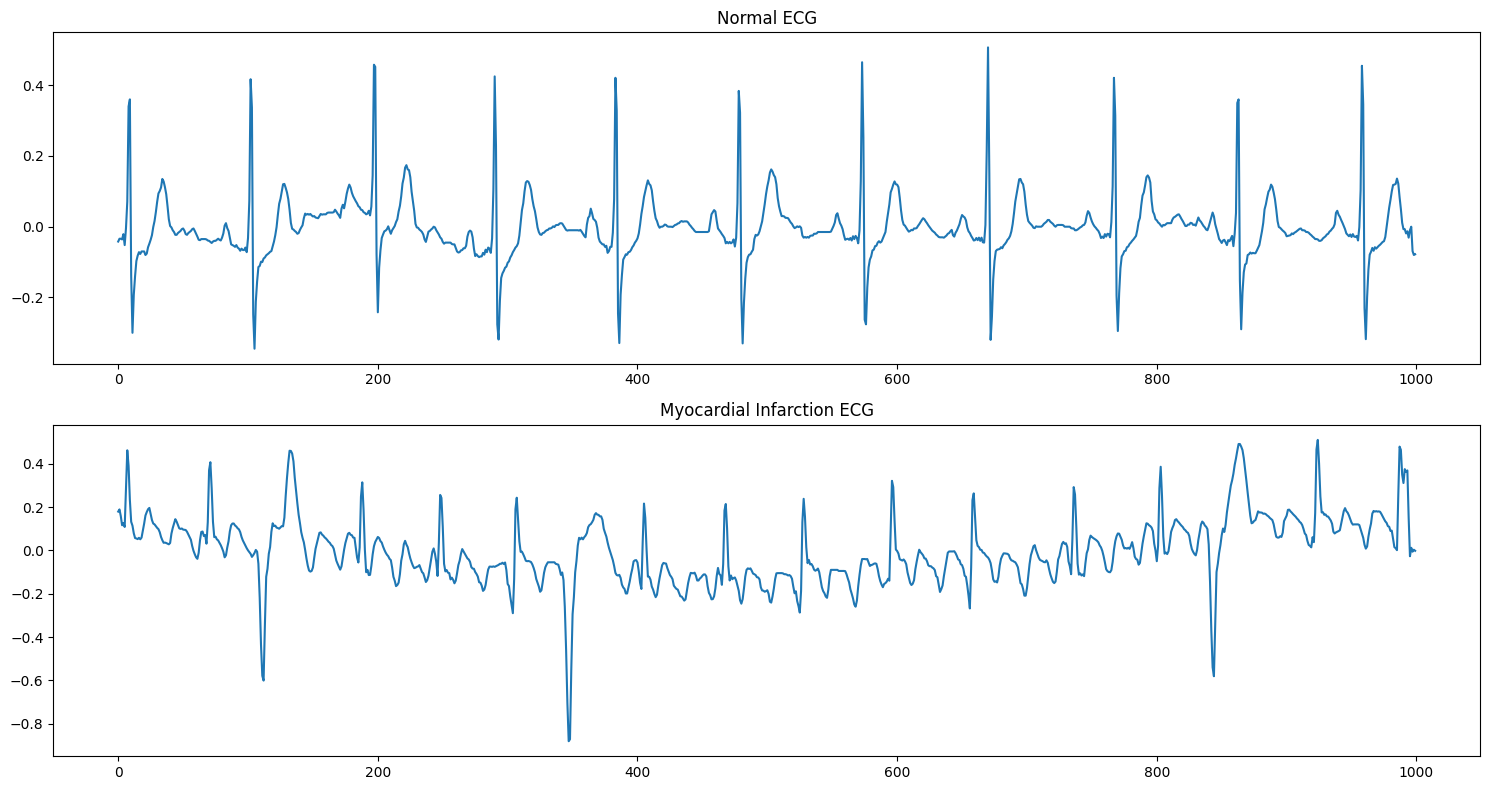

In [ ]:
norm_record = norm_df.iloc[0]
mi_record = mi_df.iloc[0]

norm_signal,_ = wfdb.rdsamp(
    f"{BASE_PATH}/{norm_record['filename_lr']}"
)

mi_signal,_ = wfdb.rdsamp(
    f"{BASE_PATH}/{mi_record['filename_lr']}"
)

lead = 1

plt.figure(figsize=(15,8))

plt.subplot(2,1,1)
plt.plot(norm_signal[:,lead])
plt.title("Normal ECG")

plt.subplot(2,1,2)
plt.plot(mi_signal[:,lead])
plt.title("Myocardial Infarction ECG")

plt.tight_layout()
plt.show()

In [ ]:
def bandpass_filter(
    data,
    lowcut=0.5,
    highcut=40,
    fs=100,
    order=5
):

    nyq = fs * 0.5

    low = lowcut / nyq
    high = highcut / nyq

    b, a = butter(
        order,
        [low, high],
        btype="band"
    )

    return filtfilt(
        b,
        a,
        data,
        axis=0
    )

def zscore(signal):

    mean = np.mean(signal, axis=0)
    std = np.std(signal, axis=0)

    return (
        signal - mean
    ) / (
        std + 1e-8
    )

def load_ecg(record_path):

    signal,_ = wfdb.rdsamp(
        record_path
    )

    signal = bandpass_filter(signal)

    signal = zscore(signal)

    return signal.astype(
        np.float32
    )

In [ ]:
import os

valid_rows = []

for _, row in data_df.iterrows():

    path = (
        f"{BASE_PATH}/"
        f"{row['filename_lr']}"
    )

    if (
        os.path.exists(path + ".dat")
        and
        os.path.exists(path + ".hea")
    ):
        valid_rows.append(row)

data_df = pd.DataFrame(valid_rows)

print(
    "최종 사용 ECG:",
    len(data_df)
)

최종 사용 ECG: 999


In [ ]:
from tqdm import tqdm
import os

X = []
y = []

for _, row in tqdm(
    data_df.iterrows(),
    total=len(data_df)
):

    try:

        path = (
            f"{BASE_PATH}/"
            f"{row['filename_lr']}"
        )

        if not (
            os.path.exists(path + ".dat")
            and
            os.path.exists(path + ".hea")
        ):
            continue

        signal = load_ecg(path)

        X.append(signal)

        y.append(row["label"])

    except Exception as e:

        print("skip:", path)

        continue

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print(X.shape)
print(y.shape)

100%|██████████| 999/999 [10:13<00:00,  1.63it/s]

(999, 1000, 12)
(999,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(799, 1000, 12)
(200, 1000, 12)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [ ]:
def transformer_encoder(
    inputs,
    head_size=32,
    num_heads=4,
    ff_dim=64,
    dropout=0.1
):

    attention = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    attention = Dropout(dropout)(
        attention
    )

    x = LayerNormalization(
        epsilon=1e-6
    )(inputs + attention)

    ff = Dense(
        ff_dim,
        activation="relu"
    )(x)

    ff = Dense(
        x.shape[-1]
    )(ff)

    ff = Dropout(dropout)(ff)

    return LayerNormalization(
        epsilon=1e-6
    )(x + ff)

In [ ]:
class AttentionPooling(
    tf.keras.layers.Layer
):

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1],1),
            initializer="glorot_uniform"
        )

    def call(self, x):

        score = tf.matmul(
            x,
            self.W
        )

        weights = tf.nn.softmax(
            score,
            axis=1
        )

        return tf.reduce_sum(
            weights * x,
            axis=1
        )

In [ ]:
inputs = Input(
    shape=(1000,12)
)

# Multi-Scale Branch

b1 = Conv1D(
    32,
    kernel_size=3,
    padding="same",
    activation="relu"
)(inputs)

b2 = Conv1D(
    32,
    kernel_size=5,
    padding="same",
    activation="relu"
)(inputs)

b3 = Conv1D(
    32,
    kernel_size=7,
    padding="same",
    activation="relu"
)(inputs)

x = Concatenate()(
    [b1,b2,b3]
)

x = BatchNormalization()(x)

x = Conv1D(
    64,
    kernel_size=3,
    padding="same",
    activation="relu"
)(x)

# Transformer
x = transformer_encoder(x)

# Attention Pooling
x = AttentionPooling()(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1000, 32)  │      1,184 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1000, 32)  │      1,952 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1000, 32)  │      2,720 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1000, 96)  │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1000, 96)  │        384 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1000, 64)  │     18,496 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1000, 64)  │     33,216 │ conv1d_3[0][0],   │
│ (MultiHeadAttentio… │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1000, 64)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1000, 64)  │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1000, 64)  │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1000, 64)  │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1000, 64)  │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1000, 64)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1000, 64)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1000, 64)  │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_pooling   │ (None, 64)        │         64 │ layer_normalizat… │
│ (AttentionPooling)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      8,320 │ attention_poolin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_3[0][0] 

 Total params: 75,041 (293.13 KB)

 Trainable params: 74,849 (292.38 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 735ms/step - accuracy: 0.7621 - auc: 0.8257 - loss: 0.5107 - val_accuracy: 0.7750 - val_auc: 0.8661 - val_loss: 0.4817
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7966 - auc: 0.8657 - loss: 0.4577 - val_accuracy: 0.7188 - val_auc: 0.8989 - val_loss: 0.5556
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8529 - auc: 0.9093 - loss: 0.3709 - val_accuracy: 0.8250 - val_auc: 0.9154 - val_loss: 0.3916
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8623 - auc: 0.9315 - loss: 0.3271 - val_accuracy: 0.8375 - val_auc: 0.9221 - val_loss: 0.3630
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8498 - auc: 0.9390 - loss: 0.3164 - val_accuracy: 0.8375 - val_auc: 0.9360 - val_loss: 0.3988
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8889 - auc: 0.9499 - loss: 0.2774 - val_accuracy: 0.8500 - val_auc: 0.9582 - val_loss: 0.3277
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69m

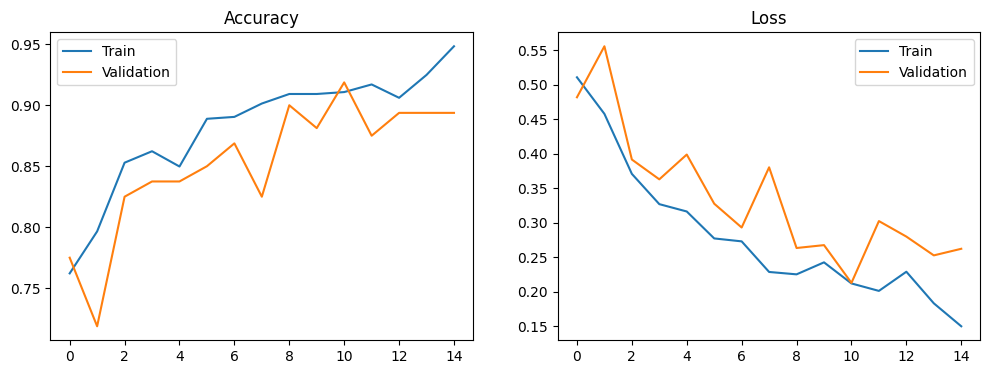

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
results = model.evaluate(
    X_test,
    y_test
)

print(results)

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 564ms/step - accuracy: 0.8650 - auc: 0.9597 - loss: 0.3334
[0.33343589305877686, 0.8650000095367432, 0.9596500396728516]


In [ ]:
y_prob = model.predict(X_test)

y_pred = (
    y_prob > 0.5
).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 371ms/step


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.91      0.81      0.86       100
         1.0       0.83      0.92      0.87       100

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200



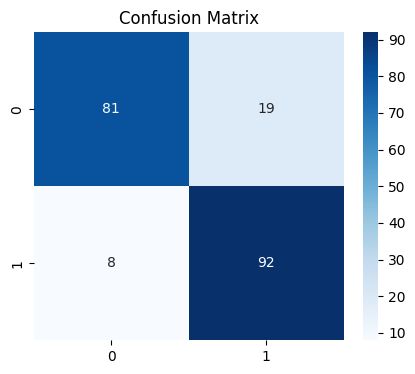

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

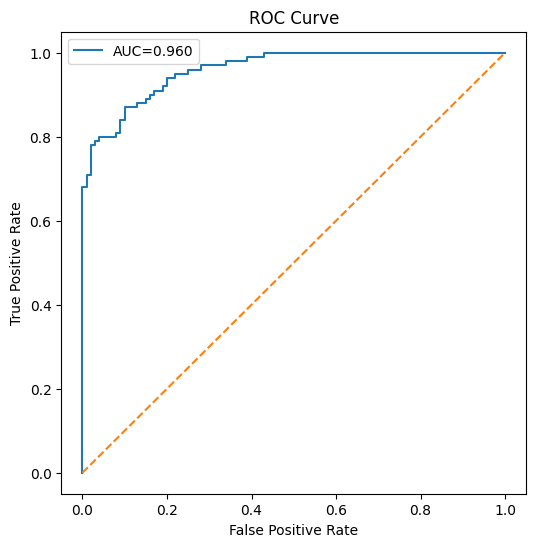

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()